In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
from pathlib import Path
import sys
import os
import json
import inspect
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/content/drive/MyDrive/large_scale_graph_final_project/Experiment2").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("Exists:", PROJECT_ROOT.exists())
print("In sys.path:", str(PROJECT_ROOT) in sys.path)
print("Top files:", sorted([p.name for p in PROJECT_ROOT.iterdir()])[:30])
print("Python files:", sorted([p.name for p in PROJECT_ROOT.glob("*.py")]))

!pip install torch_geometric

import torch
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

import recommendation_config as rcfg
print("import recommendation_config ok")
print(rcfg.__file__)

import inspect
from train_recommendation import (
    TrainConfig,
    Stage1Artifacts,
    ModelSpec,
    load_stage1_artifacts,
    train_one_model,
)

print("Imported train_recommendation successfully.")
print("RecommendationConfig signature:", inspect.signature(rcfg.RecommendationConfig))

import recommendation_config as rcfg
from train_recommendation import (
    TrainConfig,
    Stage1Artifacts,
    ModelSpec,
    load_stage1_artifacts,
    train_one_model,
)

print("Imported successfully.")
print("RecommendationConfig signature:", inspect.signature(rcfg.RecommendationConfig))

config = rcfg.RecommendationConfig()

print("Config created successfully.")
print("root       =", config.root)
print("data_dir   =", config.data_dir)
print("results_dir=", config.results_dir)

print("\nPath checks:")
print("root exists?        ", config.root.exists())
print("data_dir exists?    ", config.data_dir.exists())
print("results_dir exists? ", config.results_dir.exists())

print("\nArtifact names:")
for k, v in config.artifact_names.items():
    print(f"{k:28s} -> {v}")

stage1 = load_stage1_artifacts(config)

print("Loaded Stage1Artifacts.")
print("user_features shape:", stage1.user_features.shape)
print("item_genre_features shape:", stage1.item_genre_features.shape)
print("train_matrix shape:", stage1.train_matrix.shape)
print("source_operator shape:", stage1.source_operator.shape)
print("target_operator shape:", stage1.target_operator.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/large_scale_graph_final_project/Experiment2
Exists: True
In sys.path: True
Top files: ['.ipynb_checkpoints', 'AGENTS.md', 'Final_Project_Plan.md', 'HANDOFF_EXP3.md', '__pycache__', 'build_experiment2_combined_comparison.py', 'build_recommendation_stage1.py', 'evaluate.py', 'experiment2.ipynb', 'genre_profile_colab.py', 'graph_builder.py', 'learning curve.py', 'models.py', 'raking.py', 'recommendation_config.py', 'recommendation_data.py', 'recommendation_evaluate.py', 'recommendation_features.py', 'recommendation_graphs.py', 'recommendation_loss_sampling.py', 'recommendation_models.py', 'results', 'run_experiment2_alpha_sensitivity.py', 'run_experiment2_stage2.py', 'run_recommendation_experiment.py', 'stage1_preprocess_graphs.py', 'train.py', 'train_recommendation.py']
Python files: ['build_experiment2_combined_comparison.

In [34]:
def edge_dropout_sparse(mat: sp.csr_matrix, dropout_rate: float, rng: np.random.Generator) -> sp.csr_matrix:
    if not (0.0 <= dropout_rate < 1.0):
        raise ValueError(f"dropout_rate must be in [0,1), got {dropout_rate}")

    coo = mat.tocoo(copy=True)
    if coo.nnz == 0:
        return mat.copy().tocsr()

    keep_mask = rng.random(coo.nnz) > dropout_rate
    dropped = sp.csr_matrix(
        (coo.data[keep_mask], (coo.row[keep_mask], coo.col[keep_mask])),
        shape=mat.shape,
        dtype=coo.dtype,
    )
    return dropped.tocsr()


def edge_weight_noise_sparse(mat: sp.csr_matrix, sigma: float, rng: np.random.Generator) -> sp.csr_matrix:
    if sigma < 0:
        raise ValueError(f"sigma must be >= 0, got {sigma}")

    coo = mat.tocoo(copy=True)
    if coo.nnz == 0:
        return mat.copy().tocsr()

    noise = rng.normal(loc=0.0, scale=sigma, size=coo.nnz).astype(np.float32)
    new_data = np.clip(coo.data.astype(np.float32) + noise, a_min=0.0, a_max=None)

    noised = sp.csr_matrix(
        (new_data, (coo.row, coo.col)),
        shape=mat.shape,
        dtype=np.float32,
    )
    return noised.tocsr()


def node_feature_noise_dense(x: np.ndarray, sigma: float, rng: np.random.Generator) -> np.ndarray:
    if sigma < 0:
        raise ValueError(f"sigma must be >= 0, got {sigma}")

    noise = rng.normal(loc=0.0, scale=sigma, size=x.shape).astype(np.float32)
    return (x.astype(np.float32) + noise).astype(np.float32)

In [35]:
def make_perturbed_stage1(
    stage1: Stage1Artifacts,
    perturb_type: str | None,
    strength: float,
    seed: int = 42,
) -> Stage1Artifacts:
    rng = np.random.default_rng(seed)

    user_features = stage1.user_features.copy()
    source_operator = stage1.source_operator.copy().tocsr().astype(np.float32)
    target_operator = stage1.target_operator.copy().tocsr().astype(np.float32)

    if perturb_type is None or perturb_type == "none":
        pass

    elif perturb_type == "edge_dropout":
        source_operator = edge_dropout_sparse(source_operator, strength, rng)
        target_operator = edge_dropout_sparse(target_operator, strength, rng)

    elif perturb_type == "edge_weight_noise":
        source_operator = edge_weight_noise_sparse(source_operator, strength, rng)
        target_operator = edge_weight_noise_sparse(target_operator, strength, rng)

    elif perturb_type == "node_feature_noise":
        user_features = node_feature_noise_dense(user_features, strength, rng)

    else:
        raise ValueError(f"Unknown perturb_type: {perturb_type}")

    return Stage1Artifacts(
        user_features=user_features,
        item_genre_features=stage1.item_genre_features,
        train_matrix=stage1.train_matrix,
        val_matrix=stage1.val_matrix,
        test_matrix=stage1.test_matrix,
        candidate_item_universe=stage1.candidate_item_universe,
        user_masks=stage1.user_masks,
        source_operator=source_operator,
        target_operator=target_operator,
    )

In [36]:
TOP_MODEL_SPECS = [
    ModelSpec(
        run_name="chebnet_fused_a05",
        display_name="ChebNet fused a=0.5",
        model_kind="chebnet",
        graph="fused",
        alpha_mode="fixed",
        alpha_value=0.5,
    ),
    ModelSpec(
        run_name="graphsage_fused_a05",
        display_name="GraphSAGE fused a=0.5",
        model_kind="graphsage",
        graph="fused",
        alpha_mode="fixed",
        alpha_value=0.5,
    ),
    ModelSpec(
        run_name="fixed_fused_gcn_a05",
        display_name="GCN fused a=0.5",
        model_kind="fixed_fused",
        graph="fused",
        alpha_mode="fixed",
        alpha_value=0.5,
    ),
]
TOP_MODEL_SPECS

[ModelSpec(run_name='chebnet_fused_a05', display_name='ChebNet fused a=0.5', model_kind='chebnet', graph='fused', alpha_mode='fixed', alpha_value=0.5),
 ModelSpec(run_name='graphsage_fused_a05', display_name='GraphSAGE fused a=0.5', model_kind='graphsage', graph='fused', alpha_mode='fixed', alpha_value=0.5),
 ModelSpec(run_name='fixed_fused_gcn_a05', display_name='GCN fused a=0.5', model_kind='fixed_fused', graph='fused', alpha_mode='fixed', alpha_value=0.5)]

In [37]:
train_config = TrainConfig(
    hidden_dim=64,
    dropout=0.3,
    learning_rate=1e-3,
    weight_decay=1e-4,
    max_epochs=100,
    patience=20,
    grad_clip_norm=5.0,
    seed=42,
    eval_batch_size_users=1024,
    smoke_eval_user_limit=None,
    smoke_skip_ranking_eval=False,
    use_enriched_features=True,
    top_book_genres=30,
    highrated_sampling=False,
    highrated_threshold=4.0,
)

train_config

TrainConfig(hidden_dim=64, dropout=0.3, learning_rate=0.001, weight_decay=0.0001, max_epochs=100, patience=20, grad_clip_norm=5.0, seed=42, eval_batch_size_users=1024, smoke_eval_user_limit=None, smoke_skip_ranking_eval=False, use_enriched_features=True, top_book_genres=30, highrated_sampling=False, highrated_threshold=4.0)

In [38]:
baseline_stage1 = make_perturbed_stage1(stage1, perturb_type="none", strength=0.0, seed=42)

baseline_results, baseline_history, baseline_summary = train_one_model(
    model_spec=TOP_MODEL_SPECS[0],
    stage1=baseline_stage1,
    train_config=train_config,
    config=config,
)

baseline_results

  [features] enriched: music_top30(30) + book_train_top30(30) = 60 dims  (all-zero rows: 0)
  [epoch   1] bpr=0.6940  val_ndcg@20=0.0001  time=2.4s (sample=0.06s train=1.20s eval=1.15s)  alpha=0.5000
  [epoch   2] bpr=0.6927  val_ndcg@20=0.0001  time=1.1s (sample=0.07s train=0.05s eval=0.98s)  alpha=0.5000
  [epoch   3] bpr=0.6913  val_ndcg@20=0.0001  time=1.0s (sample=0.07s train=0.05s eval=0.86s)  alpha=0.5000
  [epoch  10] bpr=0.6812  val_ndcg@20=0.0015  time=0.7s (sample=0.07s train=0.04s eval=0.64s)  alpha=0.5000
  [epoch  20] bpr=0.6489  val_ndcg@20=0.0040  time=1.0s (sample=0.09s train=0.04s eval=0.83s)  alpha=0.5000
  [epoch  30] bpr=0.5782  val_ndcg@20=0.0041  time=0.7s (sample=0.05s train=0.04s eval=0.63s)  alpha=0.5000
  [epoch  40] bpr=0.5210  val_ndcg@20=0.0044  time=0.7s (sample=0.05s train=0.04s eval=0.62s)  alpha=0.5000
  [epoch  50] bpr=0.4733  val_ndcg@20=0.0042  time=0.7s (sample=0.06s train=0.04s eval=0.63s)  alpha=0.5000


{'model': 'ChebNet fused a=0.5',
 'graph': 'fused',
 'alpha_mode': 'fixed',
 'alpha_value': 0.5,
 'device': 'cuda',
 'best_epoch': 39,
 'epochs_ran': 59,
 'train_time_total_seconds': 48.57305732199893,
 'use_enriched_features': True,
 'highrated_sampling': False,
 'user_feature_dim': 60,
 'val_Recall@10': 0.00467364173274308,
 'val_Recall@20': 0.008024758097845947,
 'val_NDCG@10': 0.003425047789354465,
 'val_NDCG@20': 0.004392340626141965,
 'val_HitRate@20': 0.025249515864740057,
 'test_Recall@10': 0.0032773798522428557,
 'test_Recall@20': 0.005378201916702211,
 'test_NDCG@10': 0.002303726267597104,
 'test_NDCG@20': 0.0029376049563824783,
 'test_HitRate@20': 0.018396261404940287}

In [ ]:
PERTURB_GRID = {
    "edge_dropout": [0.05, 0.10, 0.20, 0.30],
    "edge_weight_noise": [0.05, 0.10, 0.20],
    "node_feature_noise": [0.05, 0.10, 0.20],
}

SEEDS = [42, 43, 44]
PERTURB_GRID

{'edge_dropout': [0.05, 0.1, 0.2, 0.3],
 'edge_weight_noise': [0.05, 0.1, 0.2],
 'node_feature_noise': [0.05, 0.1, 0.2]}

In [ ]:
all_results = []
all_histories = {}

for model_spec in TOP_MODEL_SPECS:
    for perturb_type, strengths in PERTURB_GRID.items():
        for strength in strengths:
            for seed in SEEDS:
                print("=" * 100)
                print(
                    f"Running model={model_spec.run_name} | "
                    f"perturb={perturb_type} | strength={strength} | seed={seed}"
                )

                local_train_config = TrainConfig(
                    hidden_dim=train_config.hidden_dim,
                    dropout=train_config.dropout,
                    learning_rate=train_config.learning_rate,
                    weight_decay=train_config.weight_decay,
                    max_epochs=train_config.max_epochs,
                    patience=train_config.patience,
                    grad_clip_norm=train_config.grad_clip_norm,
                    seed=seed,
                    eval_batch_size_users=2048,
                    smoke_eval_user_limit=None,
                    smoke_skip_ranking_eval=False,
                    use_enriched_features=train_config.use_enriched_features,
                    top_book_genres=train_config.top_book_genres,
                    highrated_sampling=train_config.highrated_sampling,
                    highrated_threshold=train_config.highrated_threshold,
                )

                stage1_p = make_perturbed_stage1(
                    stage1=stage1,
                    perturb_type=perturb_type,
                    strength=strength,
                    seed=seed,
                )

                results, history, summary = train_one_model(
                    model_spec=model_spec,
                    stage1=stage1_p,
                    train_config=local_train_config,
                    config=config,
                )

                row = dict(results)
                row["run_name"] = model_spec.run_name
                row["display_name"] = model_spec.display_name
                row["model_kind"] = model_spec.model_kind
                row["perturb_type"] = perturb_type
                row["perturb_strength"] = strength
                row["seed"] = seed

                all_results.append(row)
                all_histories[(model_spec.run_name, perturb_type, strength, seed)] = {
                    "history": history,
                    "summary": summary,
                }

results_df = pd.DataFrame(all_results)
results_df.head()

Running model=chebnet_fused_a05 | perturb=edge_dropout | strength=0.05 | seed=42
  [epoch   1] bpr=0.6938  val_ndcg@20=0.0001  time=0.8s (sample=0.07s train=0.04s eval=0.68s)  alpha=0.5000
  [epoch   2] bpr=0.6930  val_ndcg@20=0.0001  time=0.7s (sample=0.05s train=0.03s eval=0.65s)  alpha=0.5000
  [epoch   3] bpr=0.6924  val_ndcg@20=0.0001  time=0.9s (sample=0.06s train=0.03s eval=0.77s)  alpha=0.5000
  [epoch  10] bpr=0.6895  val_ndcg@20=0.0014  time=0.7s (sample=0.07s train=0.03s eval=0.64s)  alpha=0.5000
  [epoch  20] bpr=0.6837  val_ndcg@20=0.0021  time=0.7s (sample=0.06s train=0.03s eval=0.63s)  alpha=0.5000
  [epoch  30] bpr=0.6695  val_ndcg@20=0.0025  time=0.7s (sample=0.05s train=0.04s eval=0.63s)  alpha=0.5000
  [epoch  40] bpr=0.6410  val_ndcg@20=0.0028  time=0.9s (sample=0.07s train=0.03s eval=0.80s)  alpha=0.5000
  [epoch  50] bpr=0.6072  val_ndcg@20=0.0028  time=0.7s (sample=0.06s train=0.03s eval=0.63s)  alpha=0.5000
  [epoch  60] bpr=0.5773  val_ndcg@20=0.0027  time=0.8s

,model,graph,alpha_mode,alpha_value,device,best_epoch,epochs_ran,train_time_total_seconds,use_enriched_features,highrated_sampling,...,test_Recall@20,test_NDCG@10,test_NDCG@20,test_HitRate@20,run_name,display_name,model_kind,perturb_type,perturb_strength,seed
0,ChebNet fused a=0.5,fused,fixed,0.5,cuda,49,69,55.247271,False,False,...,0.004139,0.001585,0.002183,0.015577,chebnet_fused_a05,ChebNet fused a=0.5,chebnet,edge_dropout,0.05,42
1,ChebNet fused a=0.5,fused,fixed,0.5,cuda,43,63,49.534318,False,False,...,0.004196,0.001539,0.002169,0.015503,chebnet_fused_a05,ChebNet fused a=0.5,chebnet,edge_dropout,0.05,43
2,ChebNet fused a=0.5,fused,fixed,0.5,cuda,52,72,55.643331,False,False,...,0.003916,0.001625,0.002162,0.015577,chebnet_fused_a05,ChebNet fused a=0.5,chebnet,edge_dropout,0.05,44
3,ChebNet fused a=0.5,fused,fixed,0.5,cuda,45,65,50.140483,False,False,...,0.003684,0.001519,0.002005,0.014242,chebnet_fused_a05,ChebNet fused a=0.5,chebnet,edge_dropout,0.10,42
4,ChebNet fused a=0.5,fused,fixed,0.5,cuda,43,63,49.425828,False,False,...,0.004160,0.001516,0.002195,0.015132,chebnet_fused_a05,ChebNet fused a=0.5,chebnet,edge_dropout,0.10,43


In [ ]:
OUT_DIR = PROJECT_ROOT / "results" / "stability"
OUT_DIR.mkdir(parents=True, exist_ok=True)

results_csv = OUT_DIR / "stability_results.csv"
results_df.to_csv(results_csv, index=False)

print("Saved results to:", results_csv)
print("Rows:", len(results_df))

Saved results to: /content/drive/MyDrive/large_scale_graph_final_project-yang-744/Experiment2/results/stability/stability_results.csv
Rows: 90


In [ ]:
results_df.columns.tolist()

['model',
 'graph',
 'alpha_mode',
 'alpha_value',
 'device',
 'best_epoch',
 'epochs_ran',
 'train_time_total_seconds',
 'use_enriched_features',
 'highrated_sampling',
 'user_feature_dim',
 'val_Recall@10',
 'val_Recall@20',
 'val_NDCG@10',
 'val_NDCG@20',
 'val_HitRate@20',
 'test_Recall@10',
 'test_Recall@20',
 'test_NDCG@10',
 'test_NDCG@20',
 'test_HitRate@20',
 'run_name',
 'display_name',
 'model_kind',
 'perturb_type',
 'perturb_strength',
 'seed']

In [ ]:
candidate_ndcg_cols = [c for c in results_df.columns if "test_" in c and "NDCG@20" in c]
print("Candidate test NDCG columns:", candidate_ndcg_cols)

if len(candidate_ndcg_cols) == 0:
    raise ValueError("No test NDCG@20 column found. Please inspect results_df.columns.")
elif len(candidate_ndcg_cols) == 1:
    ndcg_col = candidate_ndcg_cols[0]
else:
    ndcg_col = candidate_ndcg_cols[0]

print("Using ndcg column:", ndcg_col)

summary_df = (
    results_df
    .groupby(["display_name", "model_kind", "perturb_type", "perturb_strength"], as_index=False)
    .agg(
        mean_test_ndcg20=(ndcg_col, "mean"),
        std_test_ndcg20=(ndcg_col, "std"),
        n_runs=(ndcg_col, "count"),
    )
    .sort_values(["perturb_type", "display_name", "perturb_strength"])
)

summary_df

Candidate test NDCG columns: ['test_NDCG@20']
Using ndcg column: test_NDCG@20


,display_name,model_kind,perturb_type,perturb_strength,mean_test_ndcg20,std_test_ndcg20,n_runs
0,ChebNet fused a=0.5,chebnet,edge_dropout,0.05,0.002172,0.000011,3
1,ChebNet fused a=0.5,chebnet,edge_dropout,0.10,0.002104,0.000095,3
2,ChebNet fused a=0.5,chebnet,edge_dropout,0.20,0.002021,0.000207,3
3,ChebNet fused a=0.5,chebnet,edge_dropout,0.30,0.002006,0.000047,3
10,GCN fused a=0.5,fixed_fused,edge_dropout,0.05,0.001832,0.000084,3
11,GCN fused a=0.5,fixed_fused,edge_dropout,0.10,0.001599,0.000145,3
12,GCN fused a=0.5,fixed_fused,edge_dropout,0.20,0.001481,0.000036,3
13,GCN fused a=0.5,fixed_fused,edge_dropout,0.30,0.001669,0.000175,3
20,GraphSAGE fused a=0.5,graphsage,edge_dropout,0.05,0.001630,0.000336,3
21,GraphSAGE fused a=0.5,graphsage,edge_dropout,0.10,0.001648,0.000333,3


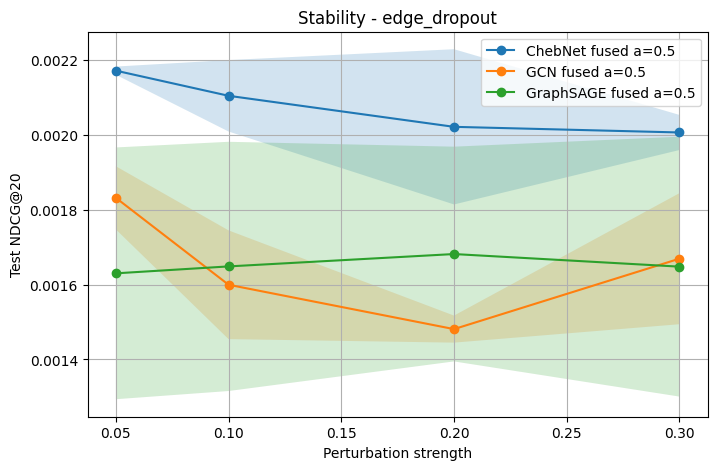

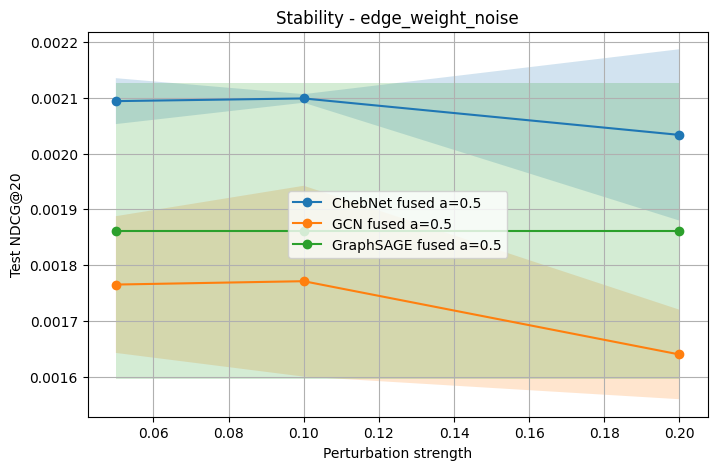

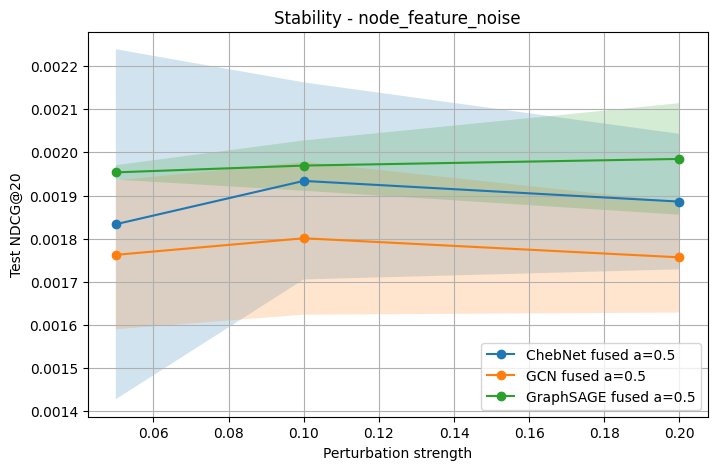

In [ ]:
for perturb_type in summary_df["perturb_type"].unique():
    plt.figure(figsize=(8, 5))

    sub = summary_df[summary_df["perturb_type"] == perturb_type].copy()

    for model_name in sub["display_name"].unique():
        cur = sub[sub["display_name"] == model_name].sort_values("perturb_strength")

        x = cur["perturb_strength"].to_numpy()
        y = cur["mean_test_ndcg20"].to_numpy()
        yerr = cur["std_test_ndcg20"].fillna(0).to_numpy()

        plt.plot(x, y, marker="o", label= model_name)
        plt.fill_between(x, y - yerr, y + yerr, alpha=0.2)

    plt.xlabel("Perturbation strength")
    plt.ylabel("Test NDCG@20")
    plt.title(f"Stability - {perturb_type}")
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
summary_csv = OUT_DIR / "stability_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print("Saved summary to:", summary_csv)

summary_df

Saved summary to: /content/drive/MyDrive/large_scale_graph_final_project-yang-744/Experiment2/results/stability/stability_summary.csv


,display_name,model_kind,perturb_type,perturb_strength,mean_test_ndcg20,std_test_ndcg20,n_runs
0,ChebNet fused a=0.5,chebnet,edge_dropout,0.05,0.002172,0.000011,3
1,ChebNet fused a=0.5,chebnet,edge_dropout,0.10,0.002104,0.000095,3
2,ChebNet fused a=0.5,chebnet,edge_dropout,0.20,0.002021,0.000207,3
3,ChebNet fused a=0.5,chebnet,edge_dropout,0.30,0.002006,0.000047,3
10,GCN fused a=0.5,fixed_fused,edge_dropout,0.05,0.001832,0.000084,3
11,GCN fused a=0.5,fixed_fused,edge_dropout,0.10,0.001599,0.000145,3
12,GCN fused a=0.5,fixed_fused,edge_dropout,0.20,0.001481,0.000036,3
13,GCN fused a=0.5,fixed_fused,edge_dropout,0.30,0.001669,0.000175,3
20,GraphSAGE fused a=0.5,graphsage,edge_dropout,0.05,0.001630,0.000336,3
21,GraphSAGE fused a=0.5,graphsage,edge_dropout,0.10,0.001648,0.000333,3


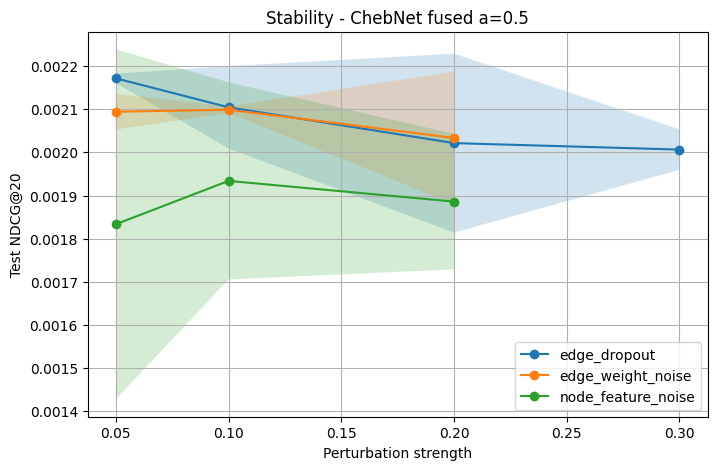

In [ ]:
target_model = TOP_MODEL_SPECS[0].display_name

plt.figure(figsize=(8, 5))
sub = summary_df[summary_df["display_name"] == target_model].copy()

for perturb_type in sub["perturb_type"].unique():
    cur = sub[sub["perturb_type"] == perturb_type].sort_values("perturb_strength")
    x = cur["perturb_strength"].to_numpy()
    y = cur["mean_test_ndcg20"].to_numpy()
    yerr = cur["std_test_ndcg20"].fillna(0).to_numpy()

    plt.plot(x, y, marker="o", label=perturb_type)
    plt.fill_between(x, y - yerr, y + yerr, alpha=0.2)

plt.xlabel("Perturbation strength")
plt.ylabel("Test NDCG@20")
plt.title(f"Stability - {target_model}")
plt.grid(True)
plt.legend()
plt.show()